# Project 03 - FACTORS INFLUENCING PLAYER'S MARKET VALUE

YOUR NAMES

Guangtong Shi, Tommy Chen

## 1. Introduction

In [37]:
#Imports here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

##### Dataset introduction

This dataset comes from "kaggle", downloaded on Feb 18, 2026, with the link https://www.kaggle.com/datasets/jayjoshi37/fifa-player-performance-and-market-value-analytics?resource=download. We downloaded it as a csv file, named "fifa_player_performance_market_value.csv". This dataset includes player demographics, position, overall rating, potential, match performance metrics (goals, assists, minutes played), contract information, and estimated market value. There are 2800 observations in total.

In [38]:
df = pd.read_csv("fifa_player_performance_market_value.csv")
df.head(10)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High


##### Research Questions

- What is the relationship between overall rating and market value (in million euros), after controlling goals, assists, and minutes played, both in the sample and in the underlying population? How does this linear regression model perform on new data?

- How do age, minutes played, and overall rating relate to the log-odds of a player being injury-prone in the sample training data? How does a classifier built on this logistic regression model perform on new data?


##### Response Variables

- For the first research question, the response variable is the market value(million euros), which is a quantitative variable, and it represents the financial value of each players.

- For the second research question, the response variable will be their injury-prone status, and this is a binary categorical variable, which indicates whether a player is injury-prone or not (Yes/No).

##### Contextual Importance

Understanding the factors that influence a player’s market value is very important, since it can also help soccer clubs to make decisions when they are buying or selling players, so that clubs can better evaluate whether a player is overvalued or undervalued in the market.

Also, analyzing factors associated with players being injury-prone is also important, especially for teams, coaches, and managers. For example, when the coach is making decisions about player training, if a large proportion of players are injury-prone, then the coach may need to adjust their trianing pace or strategies in order to reduce the risk of getting injured, and maintain player's performance. So that being able to predict their injury risk can help teams to make better decisions about training and so on, so that it could ultimately improves team's performance.

## 2. Linear Regression Analytical Tasks

##### Research Questions

- What is the relationship between overall rating and market value (in million euros), after controlling goals, assists, and minutes played, both in the sample and in the underlying population? How does this linear regression model perform on new data?

##### Split Data

In [39]:
df_train, df_test = train_test_split(df, test_size = 0.20, random_state = 666)

##### Fit Linear Regression Model

In [40]:
linear_model = smf.ols('market_value_million_eur ~ overall_rating + goals + assists + minutes_played',data = df_train).fit()
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     market_value_million_eur   R-squared:                       0.002
Model:                                  OLS   Adj. R-squared:                 -0.000
Method:                       Least Squares   F-statistic:                    0.8791
Date:                      Thu, 30 Apr 2026   Prob (F-statistic):              0.476
Time:                              18:50:34   Log-Likelihood:                -12025.
No. Observations:                      2240   AIC:                         2.406e+04
Df Residuals:                          2235   BIC:                         2.409e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         76.6332      9.245      8.289      0.000      58.504      94.763
overall_rating     0.1436      0.110      1.303      0.193      -0.072       0.360
goals              0.1284      0.095      1.352      0.176      -0.058       0.315
assists            0.0101      0.153      0.066      0.948      -0.291       0.311
minutes_played  7.224e-05      0.001      0.086      0.931      -0.002       0.002
==============================================================================
Omnibus:                     1826.879   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.590
Skew:                           0.012   Prob(JB):                     5.94e-30
Kurtosis:                       1.799   Cond. No.                     2.19e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.19e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The linear regression model will be: 

market_value_million_eur = 76.6332 + 0.1436⋅overall_rating + 0.1284⋅goals + 0.0101⋅assists + 0.00007224⋅minutes_played

##### Examine Relationships

We can see that the coefficient for the overall rating is 0.1436. This means that when holding our goals, assists, and minutes played constant, a one-unit increase in the overall rating will be associate with an increase of about approximately 0.1436 million euros in market value, which shows that there is a positive relationship between the overall rating and plaer's market value.

The 95% confidence interval for the slope of overall rating is in the range (-0.072, 0.360). This means I am 95% confident that the population slope for how overall rating affects market value (million euros), when holding goals, assists, and minutes played constant, for all football players in the dataset is in the interval (-0.072, 0.360). However, since this interval includes 0, so that it may suggests that there may be no linear relationship between the overall rating and market value in this population.

In [41]:
fitted = linear_model.fittedvalues
residuals = linear_model.resid

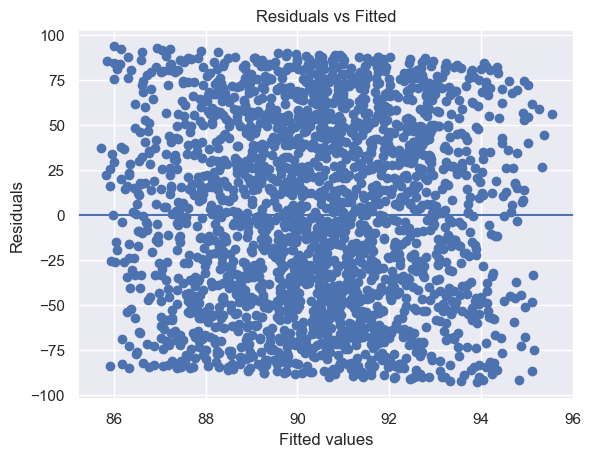

In [42]:
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

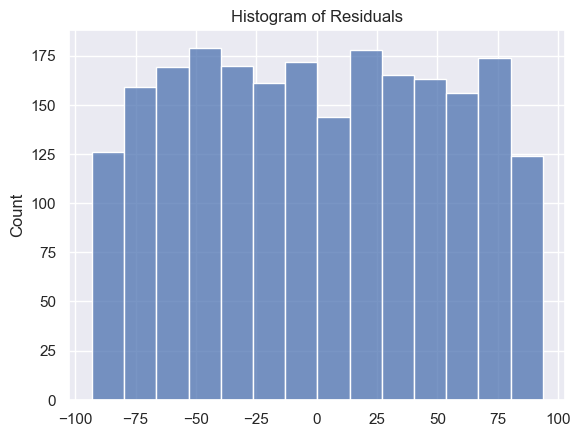

In [43]:
sns.histplot(residuals)
plt.title("Histogram of Residuals")
plt.show()

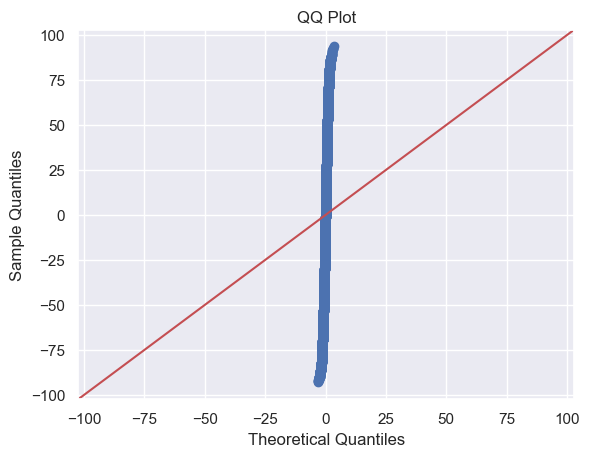

In [44]:
import statsmodels.api as sm
sm.qqplot(residuals, line='45')
plt.title("QQ Plot")
plt.show()

The residuals vs fitted graph shows that the residuals is roughly centered around zero, and there is not a clear pattern, also, the histogram of residuals does not appear to follow a clear bell shape distribution, so this suggests that the normality assumption is not well satisfied. Finally, the QQ plot shows really big deviations from the reference line, also indicates that the residuals is not normally distributed. Also combined with the very low R-squared value 0.002, this indicates that the model does not fit the data well. So that the results of the descriptive analysis and inference should be interpreted carefully.

##### Evaluate Model Performance

We can see that the R-squared value is only 0.002, which means that only 0.2% of the variation in the market value can be explained this model, and this is an extremely low value, which means this model does not provide a good fit to the data, and our selected predictors (overall rating, goals, assists, and minutes played) can not effectively explain the variation in market value.

In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_test = df_test['market_value_million_eur']
y_pred = linear_model.predict(df_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(52.649941974181935)

The RMSE on the test data is about 52.65 million euros. This means that the typical size of the error associated with this model is 52.65 million euros, and this is a rough estimate for how far an observation falls from its predicted value. Also, it is a quite large value, which further shows that this model has poor predictive performance on the data.

## 3. Logistic Regression Analytical Tasks

##### Research Question

How do age, minutes played, and overall rating relate to the log-odds of a player being injury-prone in the sample training data? How does a classifier built on this logistic regression model perform on new data?

##### Fit Logistic Regression Model

In [46]:
df_train['injury_prone_binary'] = (df_train['injury_prone'] == 'Yes').astype(int)
df_test['injury_prone_binary'] = (df_test['injury_prone'] == 'Yes').astype(int)

log_model = smf.logit('injury_prone_binary ~ age + minutes_played + overall_rating', data=df_train).fit()
log_model.summary()

Optimization terminated successfully.
         Current function value: 0.553529
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     injury_prone_binary   No. Observations:                 2240
Model:                           Logit   Df Residuals:                     2236
Method:                            MLE   Df Model:                            3
Date:                 Thu, 30 Apr 2026   Pseudo R-squ.:               0.0005660
Time:                         18:50:34   Log-Likelihood:                -1239.9
converged:                        True   LL-Null:                       -1240.6
Covariance Type:             nonrobust   LLR p-value:                    0.7045
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.0060      0.447     -2.250      0.024      -1.882      -0.130
age               -0.0083      0.007     -1.136      0.256      -0.023       0.006
minutes_played -4.259e-06   3.76e-05     -0.113      0.910    -7.8e-05    6.95e-05
overall_rating     0.0014      0.005      0.284      0.777      -0.008       0.011
==================================================================================
"""

Based on the logistic regression model summary above, the fitted model equation is:

log-odds(injury_prone = Yes) = -1.0060 + (-0.0083)·age + (-0.000004259)·minutes_played + 0.0014·overall_rating

The coefficient for **age** is -0.0083. This means that holding minutes played and overall rating constant, each additional year of age is associated with a decrease of 0.0083 in the log-odds of a player being injury-prone. Since the coefficient is negative, **lower values of age** are associated with a higher probability of being injury-prone. However, the p-value is 0.256, so this relationship is not statistically significant at the 5% level in the sample.

The coefficient for **minutes_played** is approximately -0.000004259. Holding age and overall rating constant, each additional minute played is associated with a tiny decrease in the log-odds of being injury-prone. Since the coefficient is negative, **players with fewer minutes played** are associated with a higher probability of being injury-prone. The p-value of 0.910 indicates this predictor is not statistically significant in the sample.

The coefficient for **overall_rating** is 0.0014. Holding age and minutes played constant, a one-unit increase in overall rating is associated with an increase of 0.0014 in the log-odds of being injury-prone. Since the coefficient is positive, **higher values of overall rating** are associated with a higher probability of being injury-prone. The p-value of 0.777 indicates this predictor is also not statistically significant in the sample.

None of the three predictors are statistically significant in the sample, suggesting that age, minutes played, and overall rating do not have a strong linear relationship with the log-odds of being injury-prone in this dataset.

##### Evaluate Model Fit

In [49]:
pseudo_r2 = log_model.prsquared
pseudo_r2

np.float64(0.0005659624996339208)

In [50]:
probs = log_model.predict(df_test)
y_true_arr = df_test['injury_prone_binary'].values
pos_probs = probs[y_true_arr == 1]
neg_probs = probs[y_true_arr == 0]
auc = np.mean([np.mean(p > neg_probs) + 0.5 * np.mean(p == neg_probs) for p in pos_probs])
auc

np.float64(0.49782285471537807)

The McFadden's Pseudo-R² is approximately 0.00056, which is extremely close to zero. This means that the logistic regression model using age, minutes played, and overall rating explains essentially none of the variation in injury-prone status in the training data, indicating a very poor model fit.

The AUC (Area Under the ROC Curve) on the test data is approximately 0.4978. An AUC of 0.5 corresponds to a classifier with no discriminatory power, equivalent to random guessing, while an AUC of 1.0 represents a perfect classifier. Since our AUC is essentially 0.5, the logistic regression model built on age, minutes played, and overall rating is unable to distinguish between injury-prone and non-injury-prone players on new data.

##### Build Classifier and Evaluate Performance

In [53]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
y_pred = (probs >= threshold).astype(int)
y_true = df_test['injury_prone_binary'].values

display(pd.crosstab(df_test['injury_prone_binary'], y_pred,
                    rownames=['Actual'], colnames=['Predicted']))

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

accuracy, sensitivity, specificity

Predicted,0
Actual,
0,428
1,132


(np.float64(0.7642857142857142), np.float64(0.0), np.float64(1.0))

With a classification threshold of 0.5, the classifier predicts all 560 test players as not injury-prone (i.e., no player has a predicted probability ≥ 0.5). This produces the following results:

- **Accuracy: 0.7643** — The classifier correctly labels 76.43% of test players. However, this high accuracy is misleading: it simply reflects the fact that 76.43% of players in the test set are not injury-prone. The classifier achieves this by predicting "No" for every single player.

- **Sensitivity: 0.0** — The classifier correctly identifies 0% of the injury-prone players. All 132 truly injury-prone players in the test set are incorrectly classified as not injury-prone. These are **Type II errors (false negatives)**: predicting a player is not injury-prone when they actually are.

- **Specificity: 1.0** — The classifier correctly identifies 100% of the non-injury-prone players (all 428). There are no **Type I errors (false positives)** in this classifier.

In this context, a Type II error (false negative) is more consequential: classifying an injury-prone player as not injury-prone means a team would not take precautions to manage that player's risk, potentially leading to real injuries and lost playing time. A Type I error (false positive) would incorrectly flag a healthy player as injury-prone, potentially leading to unnecessary rest or reduced training intensity.

We are **not satisfied** with the performance of this classifier. Since minimizing Type II errors (false negatives) is the most important goal in this context — we want to correctly identify injury-prone players — a classifier with a sensitivity of 0.0 is completely ineffective. It fails to flag a single injury-prone player, which means it provides no useful information to coaches or medical staff trying to manage player injury risk. A satisfactory classifier would need meaningfully higher sensitivity, even if that came at the cost of lower specificity.

## 4. Conclusion

In this project, we built a linear regression model and a logistic regression model to analyze a FIFA player performance dataset with 2800 observations. For the first research question, we modeled market value (in million euros) as a function of overall rating, goals, assists, and minutes played. The model produced an extremely low R² of 0.002 and an RMSE of approximately 52.65 million euros on the test data, indicating that these performance statistics do not effectively explain variation in player market value. The 95% confidence interval for the slope of overall rating (-0.072, 0.360) includes zero, further suggesting no significant linear relationship with market value in the population. For the second research question, we modeled injury-prone status (Yes/No) as a function of age, minutes played, and overall rating. This logistic regression model also performed very poorly: the McFadden's Pseudo-R² was 0.0006 and the AUC on the test data was approximately 0.50, indicating no better discriminatory power than random guessing. With a threshold of 0.5, the classifier predicted all players as not injury-prone, achieving a sensitivity of 0.0 and entirely missing every injury-prone player in the test set.

**Limitations:** Both models performed poorly, which may reflect limitations of the dataset itself. The FIFA dataset used here contains simulated or estimated values, and the predictors we selected (overall rating, goals, assists, minutes played, age) may not capture the true drivers of market value or injury risk. Market value is influenced by many factors not present in this dataset, such as a player's age relative to their peak, club prestige, media profile, and positional scarcity. Injury risk is similarly influenced by training load, injury history, biomechanics, and medical staff quality, none of which appear in this dataset. Additionally, linear regression assumes a linear relationship between predictors and the response, which may not hold here.

**Future Work:** Future analyses could incorporate additional predictors, such as player position, contract length, nationality, or club prestige, to better explain market value. For injury risk prediction, real-world sports science data including training load, prior injury history, and physical measurements would likely lead to far more accurate models. Exploring non-linear models (such as random forests or gradient boosting) could also capture more complex relationships in the data that linear and logistic regression cannot.

## AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class.  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

Yes, we used AI (Claude) to help guide and debug our code on this assignment.

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

- **Which AI and/or resources did you use?** We used Claude (claude.ai) to help guide and debug code for this project.

- **What prompts did you ask it?** We asked for help with fitting the logistic regression model using statsmodels, encoding the binary response variable, and computing evaluation metrics including pseudo-R², AUC, sensitivity, and specificity.

- **How did you integrate the responses into your assignment?** We used the AI to help structure the code in Sections 2 and 3 and to troubleshoot errors. All written interpretations and narrative answers were written by us. The AI was used as a coding aid, not to generate text responses.